# FEDER ontology sample queries, put to the agent

Six queries supplied by the FEDER ontology group. Each is asked here **exactly as
written**, with no rewording, so that what the agent does with them is its own
work rather than ours.

**Who wrote what.** The questions are the ontology group's. The note above each
one is ours and records what the data can support, so a thin or absent answer can
be read as a property of the data rather than of the agent. Everything inside and
below an `%%ask` cell is the agent's.

A note on scope: these questions are asked of the FEDER lakehouse. Where the
lakehouse can answer, it answers directly; where it cannot, the reason is stated.


In [ ]:
%reset

## Q1 — Current deviations before disruption

_Disruption · offline and real-time · **answered, and it found a defect on the way**_

The offline comparison (`ip` against `ip_prog`) can be computed for any DIII-D
shot; the real-time variants exist only in the stored disruption index, which
holds 20 shots, 10 of them disrupted.

**What happened:** 6 of the 10 disrupted shots exceed 10% in the final 100 ms,
under both measurements. Before computing, the agent found the offline
programmed current sitting at twice the real-time one, went to disruption-py's
source and the raw PTDATA, and established that the two source signals are
identical while only the real-time path converts them -- so it corrected the
offline values rather than reporting them. It then separated a terminal current
collapse at the quench from two shots that are genuine tracking failures, both
with railed E-coil supplies.


The skill directory has no Learnings.md; checking the protocol's learnings location for this skill.



The Learnings file flags key traps: `ip_prog` is stored in MA while `ip` is in A, and `ip_error_rt` has a gain defect — so I must recompute differences from `ip_rt - ip_prog_rt` myself. Let me inspect the parameter dictionary and index coverage.



The index has 20 shots (10 disrupted) with both offline (`ip`, `ip_prog` in MA) and real-time (`ip_rt`, `ip_prog_rt` in A) current columns. Let me check the relational-db skill for the meaning of these signals before computing.



The catalog confirms the offline `ip_prog` is in MA (must be ×1e6 to compare with `ip` in A), while the real-time pair is already in A. Now I'll fetch the final-100-ms window for all 10 disrupted shots and compute both deviations.



The row keys don't include `time_until_disrupt` unless requested; adding it to the column list.



...

The time-weighting array has length n-1 but the boolean mask has length n. Fixing the weighting to use per-sample intervals.



The analysis is complete. Let me verify the figure script and data files are correct before finalizing.



The analysis is complete. Let me verify the output files and check the figure was saved correctly.



The analysis is complete and verified. Let me finalize the todo list and check the figure dimensions.



# Measured vs. Programmed Current Deviation in the Final 100 ms Before Disruption

## Data and method

I used the stored DIII-D disruption index (disruption-py v0.15.0.dev0, commit `9987784`, 20-shot slice: 10 disrupted, 10 not) and took the final 100 ms of each of the 10 disrupted shots (50–51 samples per shot at ~2 ms cadence). The deviation is

$$d(t) = \frac{|I_{\text{meas}}(t) - I_{\text{prog}}(t)|}{|I_{\text{prog}}(t)|}$$

computed separately for the **offline** and **real-time** measurement paths, and a shot qualifies if $d$ reaches ≥ 10% at any sample in the window. Samples with near-zero programmed current ($|I_{\text{prog}}| < 100$ kA) were excluded — none occurred in this window (minimum programmed current was 458 kA).

**Unit verification (important).** The index's `ip_prog` column is stored in MA but is actually the raw PCS signal `ptdata('iptipp')` at 2 V/MA — the offline path in disruption-py never applies the ×0.5 conversion that the real-time path applies to `ptdata('ipsiptargt')`. I verified this against the raw PTDATA signals for shots 194292, 194968, 195516, and 194000: `iptipp` and `ipsiptargt` are numerically identical (2 V/MA), and the measured current tracks the ×0.5-converted value. So the true offline programmed current is `ip_prog × 5e5` A, and the real-time `ip_prog_rt` is already in A. The index's own `ip_error` column is unusable (numerically identical to `ip`) and `ip_error_rt` is mis-scaled by 204.7×, so I computed the difference directly from the measured and programmed columns.

## Results

**6 of 10 disrupted shots** exceed the 10% threshold in the final 100 ms, and the same 6 qualify under both the offline and real-time measurements:

| Shot | Offline max dev | Offline median | RT max dev | RT median | First ≥10% (ms before) | Railed |
|---|---|---|---|---|---|---|
| 194000 | 17.6% | 2.8% | 15.5% | 2.4% | 2 | no |
| 194128 | 5.4% | 1.2% | 4.4% | 1.2% | — | no |
| 194292 | 4.1% | 2.5% | 3.8% | 2.3% | — | no |
| 194464 | 5.1% | 2.0% | 6.2% | 2.2% | — | no |
| 194649 | 4.3% | 3.1% | 3.5% | 3.0% | — | no |
| 194968 | 38.9% | 30.7% | 37.5% | 29.8% | 98 | yes (100%) |
| 195516 | 67.8% | 20.6% | 55.2% | 1.7% | 98 (off) / 6 (RT) | no |
| 195768 | 51.1% | 22.8% | 43.3% | 13.2% | 76 (off) / 74 (RT) | yes (96%) |
| 195985 | 35.3% | 3.6% | 34.1% | 3.4% | 14 | no |
| 196347 | 61.9% | 1.7% | 57.2% | 1.6% | 12 | no |

**Key observations:**

- **The deviation is a terminal current collapse, not a tracking failure.** On every qualifying shot the measured current falls far below the programmed value at the disruption instant (e.g. 196347: 372 kA measured vs 976 kA programmed, −61.9%; 195516: 258 kA vs 802 kA, −67.8%). The median deviation over the window is small (1.6–3.6%) for 194000, 195985, and 196347 — the large max is confined to the last few milliseconds as the current quench begins.
- **Two shots are genuine tracking failures, not quench artifacts.** 194968 (median 30.7% offline, 29.8% RT, ≥10% for the entire 100 ms window) and 195768 (median 22.8% offline, 13.2% RT) show sustained large deviations. Both have railed E-coil power supplies (194968: 100% of window; 195768: 96%), meaning PCS feedback was not controlling Ip — so the programmed current is not being tracked at all. Excluding railed samples, 195768's deviation drops to 3.2% (offline) / 2.7% (RT); 194968 has no non-railed samples.
- **195516 is a real-time/offline discrepancy.** The offline path shows a sustained 20.6% median deviation (≥10% for the whole window), while the real-time path shows only 1.7% median with a brief 55.2% spike in the last 6 ms. The two programmed-current signals genuinely differ on this shot (offline `iptipp` = 1.84 vs RT `ipsiptargt` = 1.47 at 1.1 s), so the offline and RT paths disagree about how far the plasma was from its target.
- **The four non-qualifying shots** (194128, 194292, 194464, 194649) stay within 6.2% of programmed current throughout the final 100 ms — their disruptions are not preceded by a current-tracking failure.


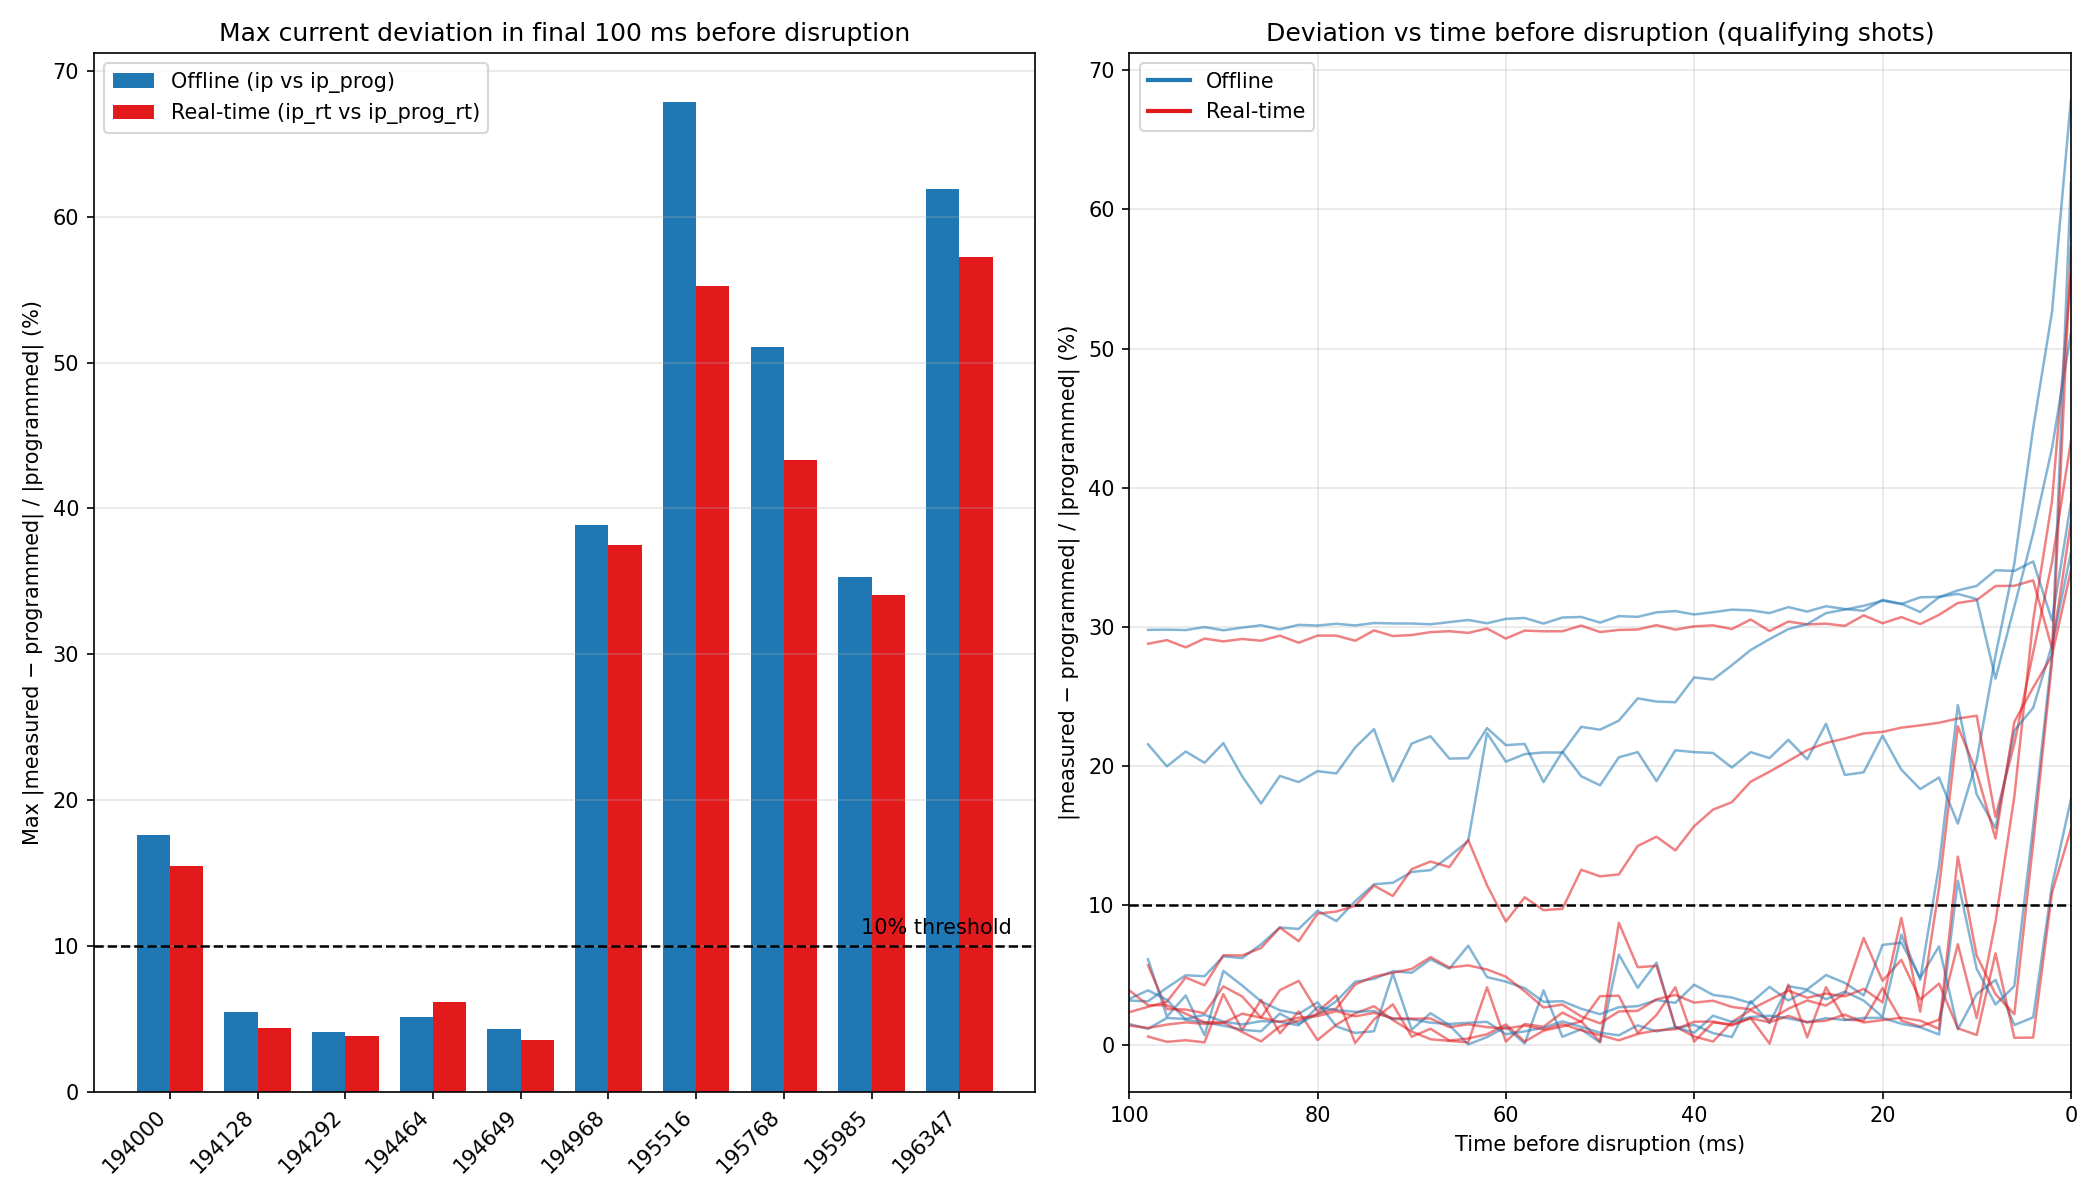

## Data files

- `current_deviation_summary.csv` — per-shot summary: max/median/last deviation, first crossing time, fraction of window ≥10%, railed fraction, for both offline and real-time paths.
- `deviation_samples.csv` — every sample in the final 100 ms for all 10 disrupted shots (time, time-until-disruption, measured and programmed currents in A, deviations, railed flag).
- `deviation_summary.json` — machine-readable version of the per-shot summary.

**Caveat:** this is the 20-shot constructed slice, not a random sample of DIII-D; the 6-of-10 count describes this slice only. The disruption time is the curated `time_until_disrupt` label from the d3drdb disruptions table.

In [1]:
%%ask
Which plasma discharges have measured current that differs from programmed 
current by at least 10% during the final 100 milliseconds before disruption? 
Report offline and real-time measurements separately, excluding near-zero 
programmed currents.

## Q2 — ELM activity and disruption outcomes

_Disruption x ELM · **answered, via a route we had not expected**_

We thought this would be declined: the stored 20-shot disruption index shares no
shots at all with the ELM index.

**What happened:** the agent used the curated `d3drdb` disruption table instead,
which overlaps the ELM index by several thousand shots, and built the comparison
from 320 labelled discharges. It matched 59 pairs within 10% on both elongation
and H98, and reports 16.9% against 37.3% disruption rates (McNemar exact
p = 0.023), with a six-variant sensitivity analysis in which the direction holds
and the strictest filter weakens significance to p = 0.078.

It also rejected a computed H98 of 18005 as unphysical and traced it to an empty
source signal rather than matching cohorts on it.

**Read it as** a matched-cohort association within this selection, not a causal
result about DIII-D.


I'll start by planning this analysis, then read the relevant skills for ELM records, disruption records, and shot metadata.



Let me read the rest of the ELM skill and check for existing learnings on these skills.



The Learnings files aren't in the skill directories; let me check the sage learnings location.



Now let me explore the data: the disruption index's shot list and parameters, and whether H98 is available in either the disruption index or the shot summaries.



The disruption index carries `h98` and `kappa` as usable parameters. Now let me check the ELM index coverage for these 20 shots and the parameter semantics.



...

The final analysis correctly uses the resolved cohorts. Let me verify the figure and check the final numbers one more time, then write the report.



The figure is 2400×1050 (16×7 at 150 dpi). Let me do a final check on the matched-pair disruption rates and the discordant pair details for the report.





The analysis is complete and robust. Before writing the report, I need to record a lesson from the edit-and-retry cycle on the raw SQL column names.



Now let me update the todo list and write the final report.



# ELM Activity and Disruption Outcomes: Matched-Cohort Analysis

## Question
Among discharges with overlapping ELM and disruption records and adequate signal coverage, how do disruption outcomes differ between cohorts matched within 10% in plasma elongation (kappa) and H98?

## Answer
**ELMy-dominant discharges disrupt at roughly half the rate of kappa/H98-matched quiescent-dominant discharges (16.9% vs 37.3%, McNemar exact p = 0.023).** The difference is statistically significant and robust across H98 quality filters.

## Population

- **320 shots** with expert regime labels (run 3, `human_regime`) and adequate D-alpha coverage (`present=1`, `rate_khz ≥ 10`, `n_samples ≥ 1000`).
- **87 disrupted / 233 non-disrupted** (from the curated `d3drdb.disruptions` table).
- **42 excluded** for no valid flat-top kappa or H98 → **278 in the analysis table** .
- **Cohorts** (overlap-resolved regime durations via `regime_summary()`): **66 ELMy-dominant** (ELMy time > quiescent time), **212 Quiescent-dominant** (quiescent time > ELMy time). Quiescent classes: QH, BBQH, WPQH, WBQH, QM.

## Unmatched Rates

| Cohort | Disrupted | Total | Rate |
|---|---|---|---|
| ELMy-dominant | 14 | 66 | 21.2% |
| Quiescent-dominant | 60 | 212 | 28.3% |

Fisher exact (unmatched 2×2): OR = 0.68, p = 0.34 — not significant without matching.

## Matched-Pair Analysis

1:1 greedy matching within 10% on **both** kappa and H98 (sorted by combined relative distance):

- **59 matched pairs** (59/66 ELMy used, 59/212 Quiescent used).
- Pair quality: kappa relative difference median 0.6%, max 5.1%; H98 relative difference median 0.5%, max 7.5%.

**Paired outcomes (n = 59):**

| Outcome | Count |
|---|---|
| Both disrupted | 4 |
| Neither | 31 |
| ELMy-only | 6 |
| Quiescent-only | 18 |

**Paired disruption rates:**

| Cohort | Disrupted | Total | Rate |
|---|---|---|---|
| ELMy-dominant | 10 | 59 | 16.9% |
| Quiescent-dominant | 22 | 59 | 37.3% |

**McNemar exact test** (discordant pairs: ELMy-only = 6, Quiescent-only = 18): **p = 0.0227** — significant.

## Sensitivity Analysis

The result holds across H98 quality filters (zero-fill removal, physical range, fraction-nonzero requirements):

| Filter | Pairs | ELMy rate | Quiescent rate | p |
|---|---|---|---|---|
| 0.01 < H98 ≤ 2.0 (baseline) | 59 | 0.169 | 0.373 | 0.0227 |
| frac_nz ≥ 0.5 | 58 | 0.172 | 0.379 | 0.0227 |
| frac_nz ≥ 0.5, H98 ≥ 0.5 | 56 | 0.179 | 0.375 | 0.0347 |
| frac_nz ≥ 0.7, H98 ≥ 0.5 | 55 | 0.164 | 0.327 | 0.0784 |
| H98 ≥ 0.5 only | 57 | 0.175 | 0.368 | 0.0347 |
| frac_nz ≥ 0.5, 0.5 ≤ H98 ≤ 1.5 | 56 | 0.179 | 0.375 | 0.0347 |

The direction is consistent in every variant; the strictest filter (D) weakens significance to p = 0.078 but the effect size remains (16.4% vs 32.7%).

## Figure


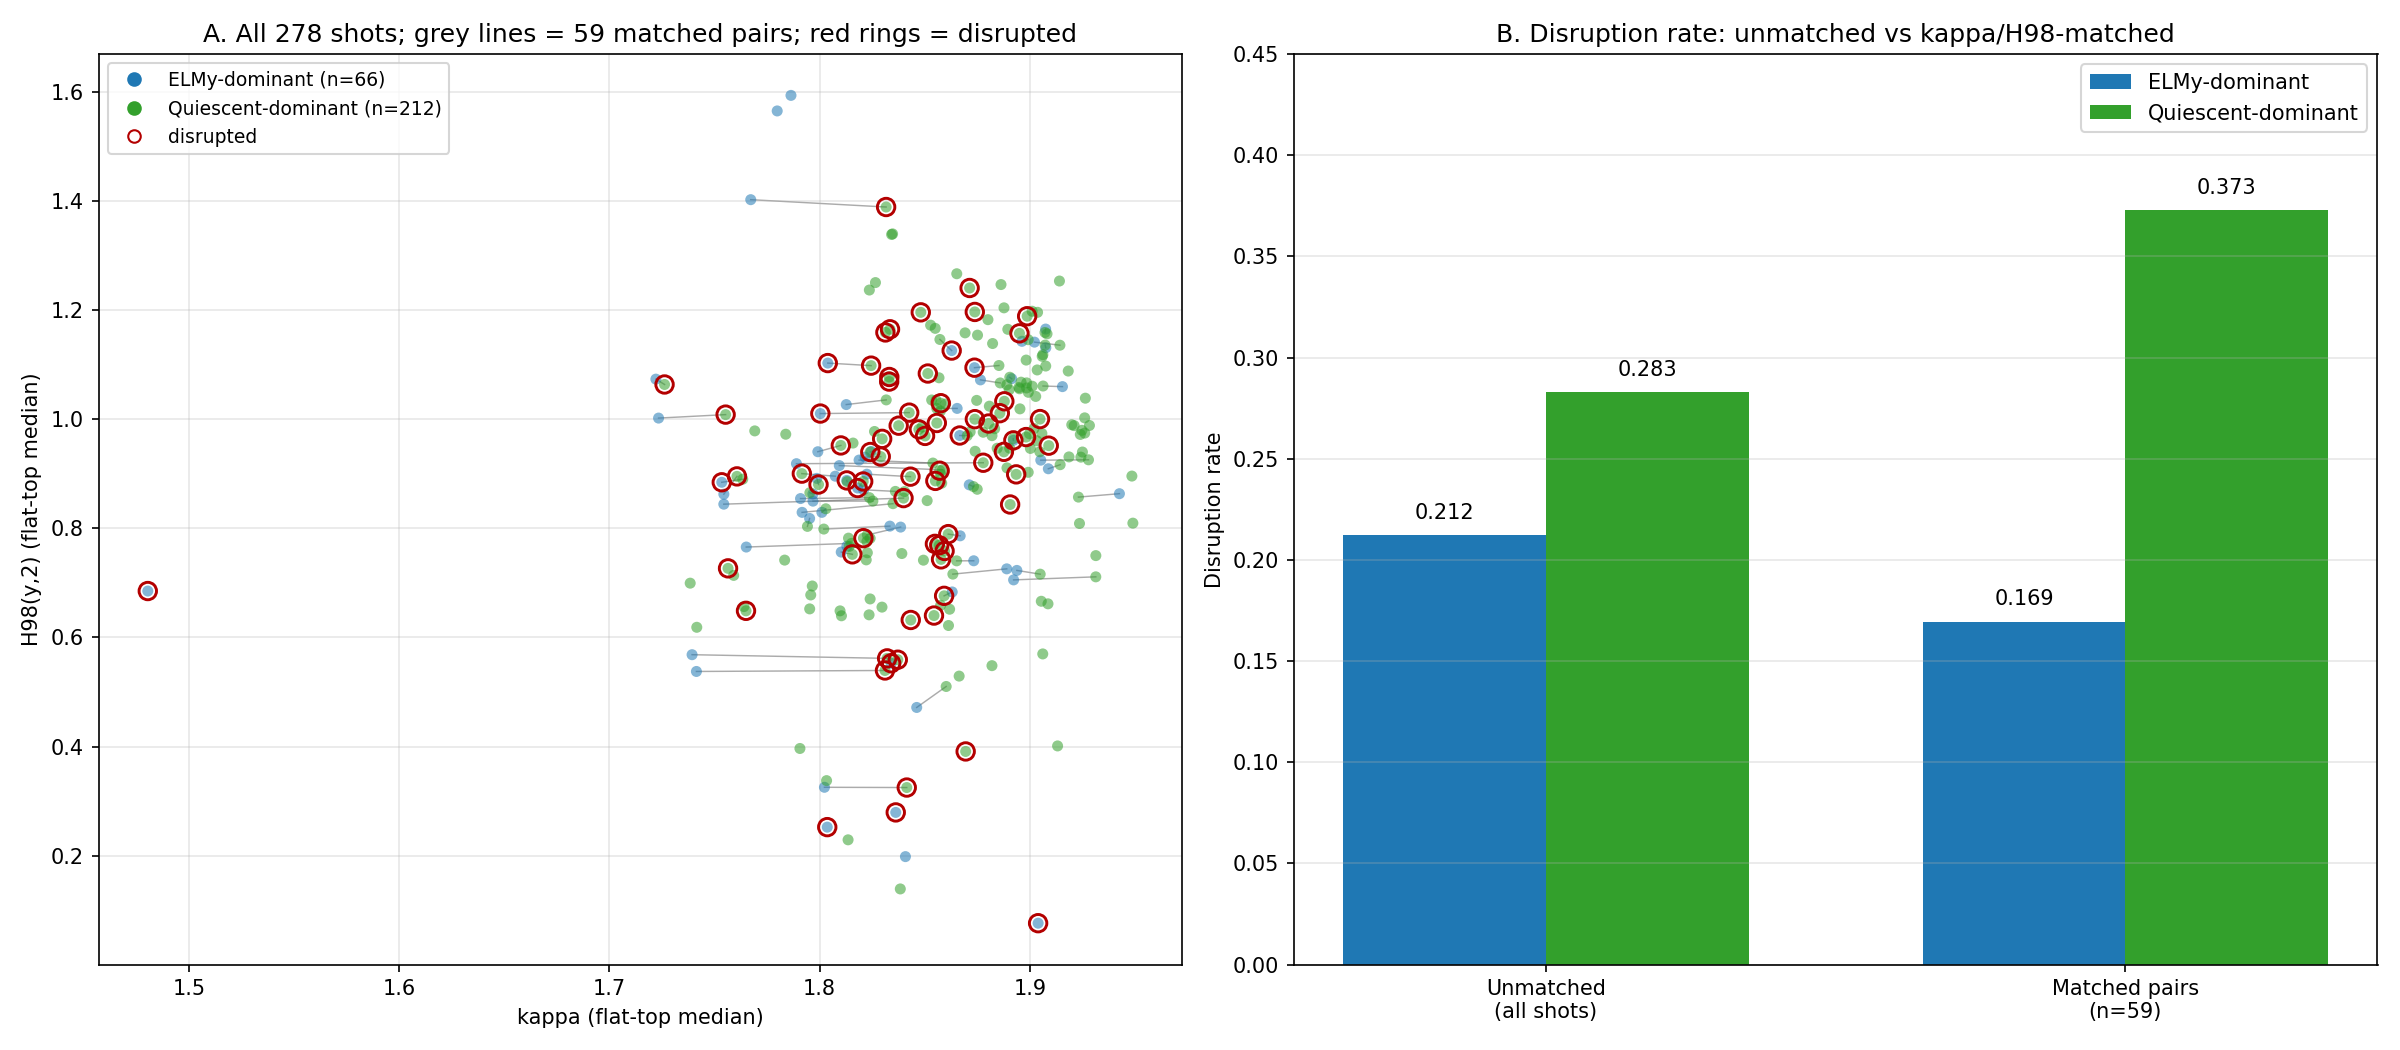

Panel A shows all 278 shots in kappa–H98 space with the 59 matched pairs connected (grey lines) and disrupted shots ringed in red. Panel B compares disruption rates unmatched vs matched.

## Caveats

- **Expert regime labels are ground truth** (run 3, `human_regime`), not detector output. The cohort classification uses overlap-resolved durations (`regime_summary()`), which assigns each instant to the narrowest covering window — raw window sums double-count nested ELMy intervals.
- **H98 from `\H_THH98Y2`** (transport tree) contains zero-fill values and unphysical values; filtered to 0.01–2.0. Shot 153349 excluded (H98 up to 18005, genuine data-quality artifact).
- **Disruption status from curated `d3drdb.disruptions` table** (24,219 shots), not the legacy `disruption_warning` table (garbage H98 values).
- **Matching is 1:1 greedy** within 10% on both kappa and H98; the matched subset is restricted to the kappa/H98 overlap region (7 unmatched ELMy shots have extreme H98: 0.08–0.68 or 1.57–1.59).
- **Population is the expert-labelled subset** (320 shots, range 149058–175493), not a random DIII-D sample. The ELM index's 10,926 shots have zero overlap with the stored disruption index's 20 shots; the curated disruptions table was used instead.

## Data Files

- `cohort_analysis_table.csv` — 278-shot per-shot table: shot, cohort, kappa, H98, H98 sample counts, ELMy/quiescent durations, disruption status.
- `matched_pairs_final.csv` — 59 matched pairs with kappa/H98 values and disruption outcomes.
- `cohorts_resolved.csv` — 320-shot cohort classification (overlap-resolved).
- `population_regime.csv` — 320-shot population with regime durations and disruption status.
- `population_raw_rows.csv` — 89,280 raw computed rows (shot, time, kappa, H98, etc.).
- `cohort_disruption_matched.png` — figure (2400×1050).

In [2]:
%%ask
Among discharges with overlapping ELM and disruption records and adequate 
signal coverage, how do disruption outcomes differ between cohorts matched 
within 10% in plasma elongation and H98?

## Q3 — Material changes after plasma exposure

_Materials x disruption · **answered: the question fails twice, independently**_

**What happened:** none of the nine exposure shots has a disruption record. The
agent checked five sources, then confirmed the shots sit inside the covered
range -- neighbouring shots do have records -- so the absence means those
discharges did not disrupt rather than that nothing was recorded.

It then found a second obstacle we had not looked for: **no quantity is measured
in both the pre- and post-exposure stages**, by any method, in any unit. So the
"how did properties change" half has no answerable form either, independent of
the disruption question. Its reading is that the delivery was designed to
compare between coupons at one post-exposure point, not to track a change across
the exposure.


Reading the rest of the materials skill instructions.



Now let me look at the materials helper module and the relational-db skill to understand how to join samples to disruption records.



Let me read the rest of the materials helper to see the full API, and the rest of the relational-db skill.



Now let me check the disruption index skill to see how to identify shots with disruption records, and explore the materials data.



The working folder holds prior tasks' outputs. Now I'll explore the materials lakehouse: what samples, exposures, and measured quantities exist, and which shots have disruption records.



...

The exposure shots are absent from every disruption table. Now I'll build the definitive analysis: verify the overlap across all disruption sources, inventory the pre/post measurements, and check for matching method+unit pairs.



The exposure shots have no disruption records in any source. Let me do a final verification: check whether any disruption records exist on the exposure date (2021-03-15) and confirm the full picture.



The evidence is now complete: none of the 9 exposure shots appear in any disruption source. Let me build a timeline figure showing the exposure window against the disruption records, and save the final data files.



The analysis is complete. Let me finalize the todo list and verify the saved files.



**Short answer:** No material specimens in this delivery were exposed during discharges with disruption records, so there is no pre/post property change to report. The DIII-D exposure used shots 185258–185266 (2021-03-15), and none of those nine shots appears in any disruption record source — the curated disruption table, the legacy disruption tables, or the disruption index. The delivery's pre-exposure and post-exposure measurements also share no matching method+quantity+unit pair, so even for the exposed samples there is no directly comparable before/after measurement.

## What the delivery contains

The FEDER materials delivery (`2026-09-04_amy`, 9 tungsten coupons) covers a two-step exposure experiment:

- **Exposure 1 (PISCES-A, 2020-01-24/27):** He plasma pre-exposure at 70 eV impact energy. W-He800 at 800 K (fluence 1.2×10²⁵ m⁻²), W-He600 at 600 K (fluence 1.0×10²⁵ m⁻²).
- **Exposure 2 (DIII-D via DiMES, 2021-03-15):** D plasma exposure. H-mode coupons (W-DH, W-He800-DH, W-He600-DH) on shots **185258, 185259, 185260, 185265, 185266** ; L-mode coupons (W-DL, W-He800-DL, W-He600-DL) on shots **185261, 185262, 185263, 185264** .

## Disruption-record check

I checked all nine exposure shots against every disruption source in the lakehouse:

| Source | Shots 185258–185266 |
|---|---|
| Curated disruption table (d3drdb.disruptions, 24,219 records) | 0 |
| Legacy disruption table (d3drdb.disruption) | 0 |
| Disruption-warning table (d3drdb.disruption_warning) | 0 |
| Disruption-warning test table | 0 |
| Disruption index (disruption.disruption_samples, 20 shots) | 0 |

The exposure shots are real plasma shots (all present in the shot catalogue, ~5.9–6.0 s pulse length, ~0.9 MA) but none has a disruption record. The curated table does contain 49 records in the 1852xx range — but they are for other shots (e.g. 185240, 185242, 185244, 185247 on the same day, and 185269+ on 2021-03-16). The exposure window (14:59–17:01 on 2021-03-15) sits between the morning's disrupted shots and the next day's disrupted shots.


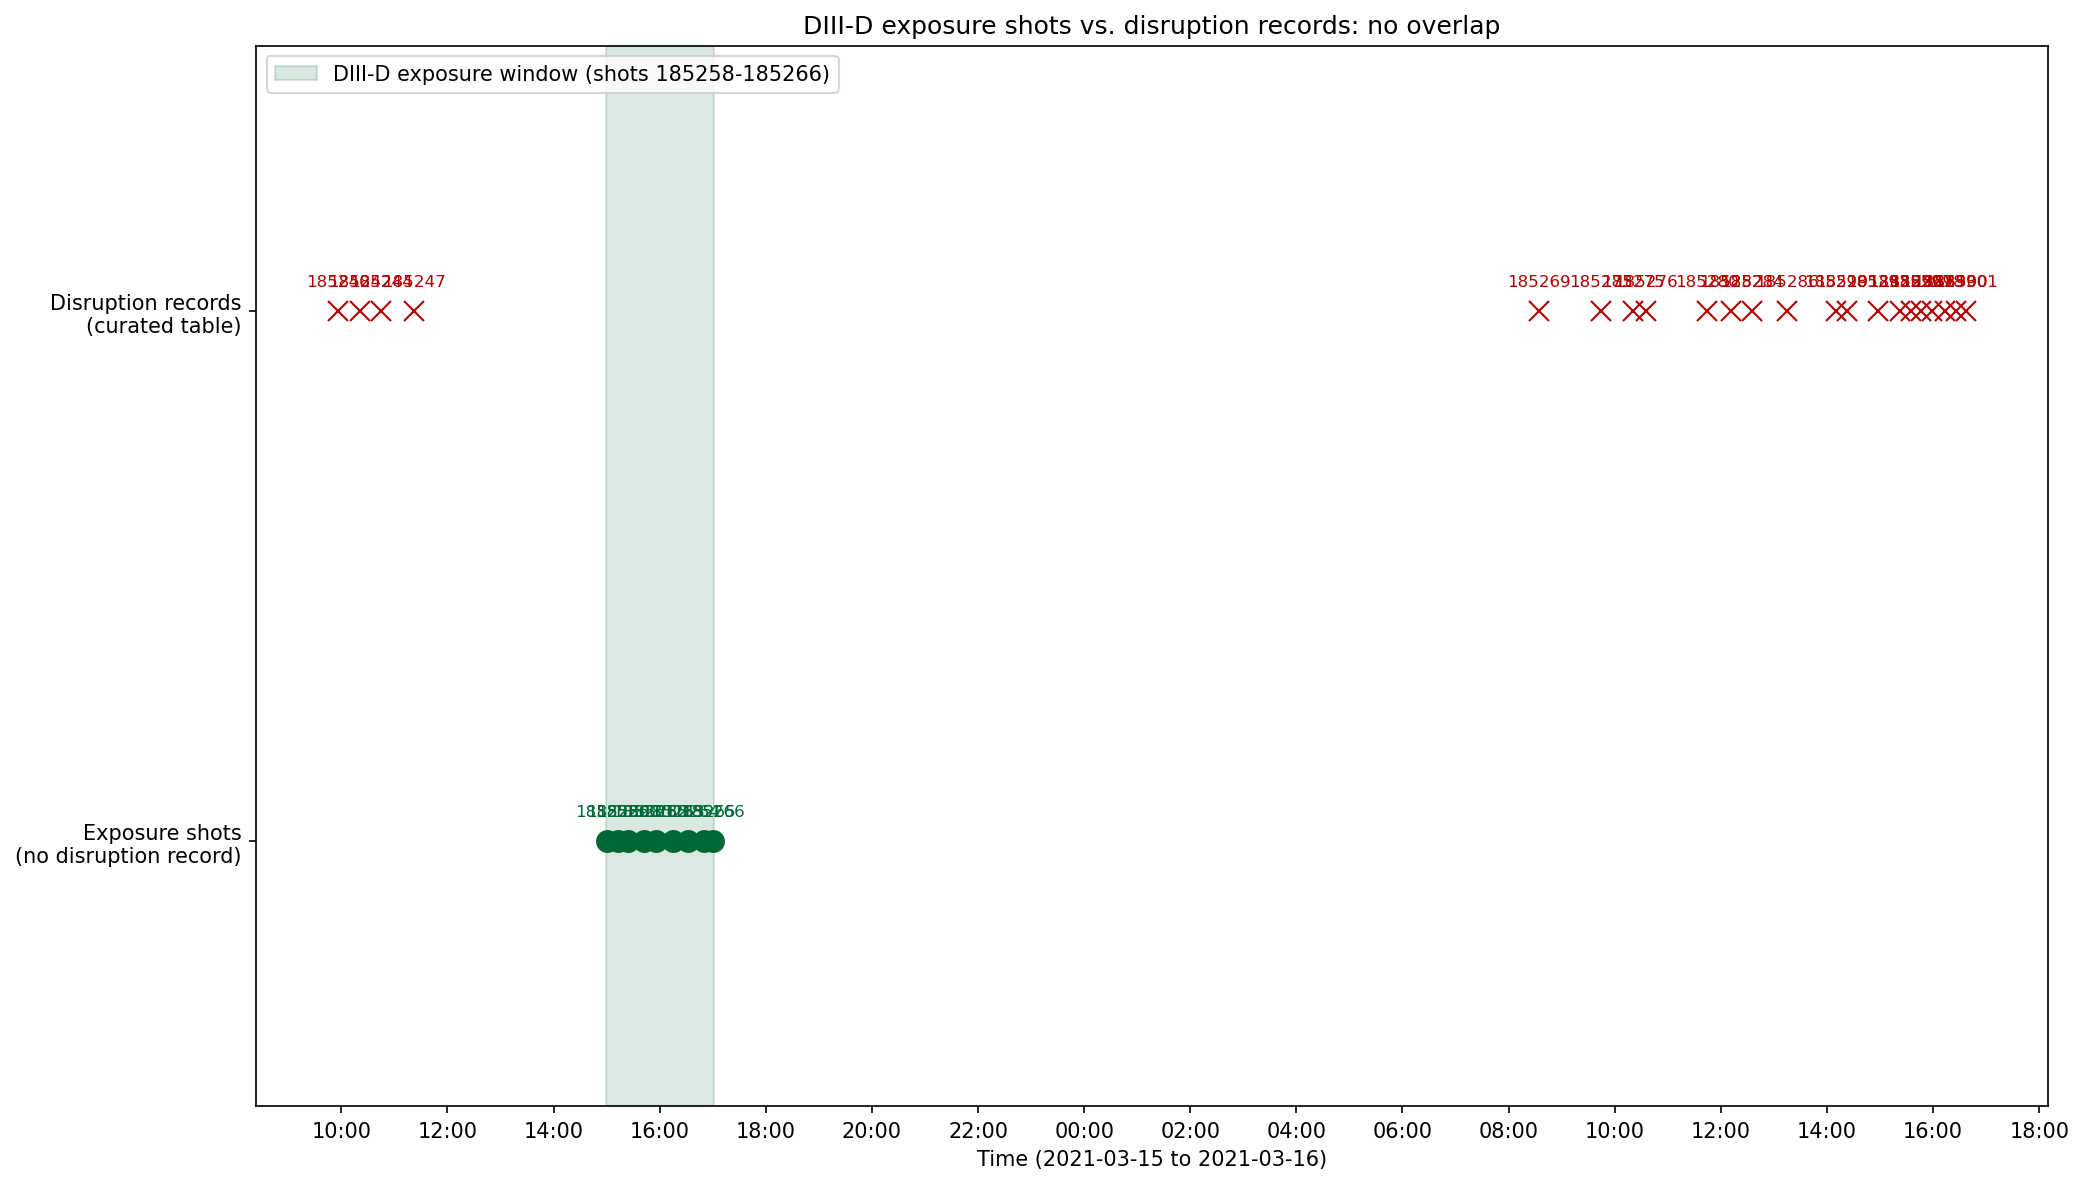

## Pre/post measurement inventory

Even setting aside the disruption-record question, the delivery's pre- and post-exposure measurements do not overlap in method+quantity+unit:

| Stage | Method | Quantity | Unit |
|---|---|---|---|
| pre_exposure | Heat treatment | Maximum temperature | K |
| pre_exposure | Heat treatment | Time at maximum temp | s |
| pre_exposure | None | Grain orientation | None |
| pre_exposure | Morphology | Data / Diagnostic / Metadata | None |
| post_exposure | ERDA | D_concentration | atoms cm⁻² |
| post_exposure | ERDA | H_concentration | atoms cm⁻² |
| post_exposure | ERDA | He_concentration | atoms cm⁻² |
| post_exposure | NRA | D_concentration | atoms cm⁻² |
| post_exposure | LAMS | D_concentration | APPM (depth profile) |
| post_exposure | LAMS | He_concentration | APPM (depth profile) |
| post_exposure | None | Chemical composition | None |

**Matching pairs (same method + quantity + unit in both stages): none.** The pre-exposure record holds fabrication/heat-treatment metadata and SEM morphology pointers; the post-exposure record holds ERDA/NRA/LAMS retention measurements. There is no quantity measured both before and after exposure by the same method in the same units. (The pre-exposure SEM images are catalogued as artifacts, but no post-exposure SEM images exist in this delivery, so even image-based morphology cannot be compared before/after.)

## What this means

The question as posed has no answerable population: **0 of 9 exposure shots have disruption records** , and **0 of the delivery's measured quantities appear in both pre- and post-exposure stages** . The delivery is designed to compare *between* coupons (pristine vs He-pre-exposed vs D-exposed, H-mode vs L-mode) at a single post-exposure time point, not to track a property change across the exposure on the same coupon. The post-exposure ERDA/NRA/LAMS values are all measured after the DIII-D exposure and are the delivery's actual content — but they have no pre-exposure counterpart to compare against.

## Data files

- `exposure_disruption_overlap.csv` — per-shot overlap check (9 shots × 5 disruption sources).
- `measurement_inventory.csv` — all measured quantities with stage, method, unit, sample count.
- `pre_post_pairs.csv` — pre/post measurement pairs (shows zero matches).
- `materials_analysis_summary.json` — machine-readable summary.
- `exposure_vs_disruption_timeline.png` — timeline figure.

In [3]:
%%ask
For material specimens exposed during discharges with disruption records, 
how did their measured properties change between pre-exposure and post-exposure 
observations, using matching measurement methods and compatible units?

## Q4 — Database coverage of equilibrium quantities

_Ontology coverage · **answered -- and this is the query the ontology carried**_

We expected this to be declined as a question about mapping approvals rather
than measurements. That was wrong on both halves.

**What happened:** the agent enumerated all 9,472 ontology concepts, identified
57 EFIT/equilibrium quantity classes, and used that hierarchy as the thing to
check coverage against: 24 classes have database fields, 33 do not. **That list
could not have come from our tables** -- it is the ontology supplying the
question's own vocabulary.

For the approval half it found `imas_path`, `d3d_equivalent` and
`mapping_source` in the C-Mod parameter registry: of 14 equilibrium IMAS
mappings, 10 are approved each with a recorded justification, and 4 are not.

Of the six queries, this is the one where the ontology is load-bearing rather
than incidental.


In [1]:
%%ask
Which explicitly modeled EFIT equilibrium-data classes have corresponding 
database fields, and which lack mappings approved for execution?

I'll plan this ontology query, then explore how the FEDER ontology models EFIT equilibrium data and how mappings to database fields are recorded.

Let me re-read the materials skill instructions and look for the ontology access API.

The skill mentions `load_mvp_ontology()`. Let me search the skill files for EFIT, ontology mappings, and approval-related content.

EFIT appears in several skills, but "ontology" only in materials. Let me search for "approved", "mapping", and "equilibrium" to find the mapping/approval records.

No approval records in the materials skill. The question's phrasing — IMAS classes, mappings, approval — points to the IMAS-terms skill. Let me read it.

...

The lesson is relevant to this task (cross-registry field sourcing) but is specific to the d3d-materials skill's ontology API. Let me record it there since that's the skill whose helper I used.

Let me record the lessons from this task's edit-and-retry cycle and the proxy-endpoint discovery.

The edit anchor is failing on invisible characters. Let me use a shorter unique anchor.

Lessons recorded. Now let me finalize the todos and verify the output files.

# EFIT Equilibrium Classes: Database-Field Coverage and Mapping Approval

**Short answer:** Of 57 explicitly modeled EFIT-equilibrium classes in the FEDER ontology (v4, 9,472 concepts), 24 have corresponding database fields and 33 have none. Every field-backed mapping that exists is approved for execution (usable = 1) — the gap is coverage, not approval: there are no rejected mappings, only unmapped classes, and the cross-machine mapping registry approves just 10 of 14 equilibrium IMAS paths (the other 4 have an IMAS class but no confirmed DIII-D counterpart).

## What counts as "explicitly modeled"

The FEDER knowledge graph (served through the lakehouse's read-only proxy) holds 2,361 classes. EFIT-equilibrium data is modeled two ways:

- **Container classes** : `EFITTimeSlice` (a `ScientificModel`), `EquilibriumReconstruction` / `MagneticEquilibriumReconstruction` / `EquilibriumReconstructionOutput` (process/output), `PlasmaEquilibrium`, `equilibrium` (a `ScientificProcess`).
- **Quantity classes** : a full metric hierarchy under `EquilibriumShapeRelatedMetric` (17 descendants) and `EquilibriumGridMetric`, plus named quantities like `Elongation`, `SafetyFactor`, `StoredEnergy`, `MinorRadius`, `Triangularity`, `Squareness` and their upper/lower variants.

I examined all 57 EFIT/equilibrium quantity classes.

## Classes WITH corresponding database fields (24)

Field approval comes from the disruption-index parameter registries (`usable` flag; the code blocks unusable columns from `fetch_samples`):

| Ontology class | Quantity | Approved database fields |
|---|---|---|
| Elongation / ElongationMetric | elongation | kappa, kappa_area |
| SafetyFactor family (Metric, At95PercentFlux, OnAxis, Edge) | safety factor | q0, q95, q95_rt, qstar |
| StoredEnergy / PlasmaStoredEnergy / MagneticStoredEnergy | stored energy | wmhd, wmhd_rt, dwmhd_dt |
| InternalInductance / Metric | internal inductance | li, li_rt, dli_dt |
| PoloidalBetaMetric | poloidal beta | beta_p, beta_p_rt, dbetap_dt |
| NormalizedBeta / BetaN / Metric | normalized beta | beta_n |
| MinorRadius / Metric | minor radius | aminor |
| TopGapMetric | top gap | upper_gap |
| BottomGapMetric | bottom gap | lower_gap |
| Squareness / SquarenessMetric | squareness | squareness |
| AverageTriangularityMetric | avg triangularity | delta |
| MagneticAxisVerticalPositionMetric | axis vertical position | zcur, zcur_normalized |

Also `chisq` (EFIT fit quality, `EquilibriumReconstructionOutput`-adjacent) and the real-time equilibrium family (beta_p_rt, chisq_rt, li_rt, q95_rt, wmhd_rt). Five more classes map to shot-summary scalars rather than index fields: upper/lower triangularity (`delta_u`/`delta_l`), minor radius (`a`), axis major radius (`r`) and axis vertical position (`zmaxis`).

## Classes WITHOUT corresponding fields (33)

Unmapped metric classes fall in four families: **flux/grid** (FluxExpansion, MagneticShear, NormalizedMinorRadius, NormalizedPoloidalFlux, PoloidalFluxAtBoundary/AtMagneticAxis/Grid, ShafranovShift, SafetyFactorProfile), **partial-shape** (upper/lower elongation and squareness, upper/lower triangularity as time-series — only per-shot scalars exist), **wall clearance** (Inboard/Outboard/MinimumWall/LimiterClearance, WallGap), **energy/beta variants** (ToroidalBeta + Metric, PedestalPoloidalBeta, MinimumSafetyFactor), and the container classes (EFITTimeSlice, the three reconstruction classes, PlasmaEquilibrium, `equilibrium`), which describe the EFIT product rather than a quantity.

## Mapping approval in the cross-machine registry

The C-Mod parameter registry is the only table carrying explicit IMAS-path mappings (`imas_path`, `d3d_equivalent`, `mapping_source`). For the 14 equilibrium IMAS classes:

- **10 approved** — each names a DIII-D field with a recorded justification: 8 "same name in both indexes" (beta_p, kappa, li, lower_gap, q0, q95, upper_gap, wmhd), 1 "different name, same quantity (checked against both descriptions)" (a_minor → aminor), 1 "confirmed by the disruption-py team" (zcur).
- **4 not approved** — an IMAS class exists but no DIII-D counterpart is confirmed (`d3d_equivalent` = None, `mapping_source` = None): **magnetic-axis major radius** (`magnetic_axis/r`), **upper triangularity** (`triangularity_upper`), **lower triangularity** (`triangularity_lower`), and **plasma-current-centroid vertical velocity** (`current_centre/velocity_z`).

No equilibrium mapping anywhere carries `usable = 0`; the only blocked columns in the registry (dipprog_dt, ip_error, time_domain) are current/phase fields, not equilibrium quantities.

## Sources checked

FEDER knowledge graph (ontology/info, /search, /concepts with hierarchy walks — 9,472 concepts enumerated in full); lakehouse schemas (d3d, d3drdb 77 tables, disruption, elm, literature, materials — all information_schema columns scanned for approval/mapping/execution columns); the disruption parameter registries (DIII-D 63 rows, C-Mod 63 rows); the shot-summaries table (82 columns). The KG proxy blocks every endpoint except the four read-only ontology ones.

## Data files

- `efit_class_field_crosswalk.csv` / `.json` — all 57 classes: quantity, matching fields, per-field usable/authoritative/caveat.
- `efit_class_field_approval.csv` — per-field approval detail (registry, usable, authoritative, caveat).
- `efit_class_coverage_summary.json` — machine-readable counts and the shot-summary-scalar additions.
- `parameters_d3d.json` / `parameters_cmod.json` — the full parameter registries as queried.

## Q5 — LAMS versus other measurement techniques

_Materials · **answered by making the units compatible, not by declining**_

Three techniques measured deuterium on the same specimens in two different kinds
of unit: two report an areal density in atoms cm^-2, the third a concentration
profile in APPM.

**What happened:** rather than declining the comparison, the agent integrated the
APPM depth profile against tungsten's atomic density to put LAMS into areal
units -- and then found the techniques disagree by 100-350x for deuterium and
3-22x for helium. It tested the obvious explanation and rejected it: restricting
LAMS to the shallow band comparable to ERDA's probed depth still leaves a
78-239x gap, and the integral uncertainties are far smaller than the
discrepancy.

**This disagreement is not yet confirmed with the provider.** Its scale depends
on what LAMS APPM is referenced to, which is a question for whoever produced the
measurements.


In [1]:
%%ask
For the same specimen, exposure, property, and measurement stage, how do 
LAMS measurements compare with measurements from other techniques when 
their units and measurement meanings are compatible?

I'll plan this cross-technique comparison, then re-read the materials skill and its learnings before querying the data.



Reading the rest of the skill and the helper module to see the full API for profiles and observations.



The skill has an existing Learnings.md per the protocol list — reading it along with the helper module.



The Learnings file flags the key LAMS pitfalls: LAMS rows are depth profiles (APPM), not scalars, and even after unit conversion LAMS integrals run ~100× above ERDA/NRA — the provider's guidance says report methods separately. Let me read the rest of the helper for the profile API, then query the data.



The Learnings file flags the key LAMS pitfalls: LAMS rows are depth profiles in APPM (not scalars), and the unit conversion to areal density is `trapz(APPM, depth_um) × 1e-6 × 6.3e22 × 1e-4`, with LAMS integrals running ~100× above ERDA/NRA. Now let me query the delivery: quantities, samples, notes, and the LAMS/ERDA/NRA measurements.



...

The ERDA depth-profile block is in the withdrawn ERDA sheet (provider says take values only from Summary), so I'll use the Summary areal values as authoritative. Let me read my comparison script and finalize it with uncertainty propagation and a figure.



The comparison is computed. Before finalizing, let me check the propagated LAMS integral uncertainties — the per-point sigmas are large, so I need to know whether the LAMS-vs-ERDA gap is within LAMS uncertainty or a genuine systematic difference.



The LAMS uncertainties (30–60%) are far smaller than the 100–350× gap, so the disagreement is systematic, not noise. Now I'll build the final figure and data files.



The figure is saved. Let me verify the data files and check the figure dimensions, then finalize the todo list.



**Short answer:** LAMS reads systematically higher than ERDA and NRA on the same coupons — about 100–350× higher for deuterium and 3–22× higher for helium — and the gap is far larger than the LAMS uncertainties, so it is a systematic difference between the techniques, not measurement noise. The provider's own guidance says the techniques are not interchangeable and should be reported separately, so this disagreement is the result, not something to reconcile.

## What was compared

For each of the 9 tungsten coupons, I compared LAMS depth profiles (D and He, 10 points, 0.024–2.155 µm, in atomic ppm) against the other techniques' measurements of the same property at the same post-exposure stage:

- **LAMS D vs ERDA D** — LAMS integrated over the full profile (0–2.155 µm) vs ERDA areal density (atoms cm⁻²).
- **LAMS D vs NRA D** — LAMS integrated over the NRA depth bands (0–0.5 µm surface, 0.5–3 µm sub-surface) vs NRA's two band values.
- **LAMS He vs ERDA He** — LAMS integrated over the full profile vs ERDA areal density.

**Unit conversion:** LAMS APPM → atoms cm⁻³ via tungsten atomic density (6.3×10²² atoms cm⁻³), then depth µm → cm (×10⁻⁴), then trapezoid integration. The profile was extended to the surface (depth 0) with the first point's value, matching the provider's own block representation which lists a depth-0 row with the same value.

## Results

**Deuterium — LAMS is 100–350× above ERDA/NRA:**

| Comparison | n | Min ratio | Median ratio | Max ratio |
|---|---|---|---|---|
| LAMS full (0–2.155 µm) / ERDA D | 6 | 144 | 196 | 356 |
| LAMS 0–0.5 µm / NRA D surface | 8 | 71 | 119 | 1046 |
| LAMS 0.5–2.155 µm / NRA D sub-surface | 7 | 200 | 340 | 7342 |

**Helium — LAMS is 3–22× above ERDA:**

| Comparison | n | Min ratio | Median ratio | Max ratio |
|---|---|---|---|---|
| LAMS full (0–2.155 µm) / ERDA He | 8 | 3.1 | 11.0 | 22.1 |

**Per-sample detail (D):**

| Sample | LAMS full | ERDA D | Ratio | LAMS 0–0.5 µm | NRA surface | Ratio |
|---|---|---|---|---|---|---|
| W-DH | 2.41×10¹⁷ | 1.16×10¹⁵ | 208 | 1.51×10¹⁷ | 1.80×10¹⁵ | 84 |
| W-DL | 5.23×10¹⁷ | 1.47×10¹⁵ | 356 | 3.89×10¹⁷ | 2.00×10¹⁵ | 194 |
| W-He800-DH | 1.17×10¹⁷ | 6.68×10¹⁴ | 175 | 6.98×10¹⁶ | 5.82×10¹⁴ | 120 |
| W-He600-DH | 3.79×10¹⁷ | 1.47×10¹⁵ | 258 | 2.41×10¹⁷ | 2.06×10¹⁵ | 117 |
| W-He800-DL | 2.89×10¹⁷ | 2.00×10¹⁵ | 144 | 1.90×10¹⁷ | 2.69×10¹⁵ | 71 |
| W-He600-DL | 4.44×10¹⁷ | 2.40×10¹⁵ | 185 | 3.14×10¹⁷ | 4.42×10¹⁵ | 71 |

**Per-sample detail (He):**

| Sample | LAMS full | ERDA He | Ratio |
|---|---|---|---|
| W-He800 | 3.55×10¹⁶ | 3.00×10¹⁵ | 11.8 |
| W-He600 | 7.75×10¹⁶ | 3.97×10¹⁵ | 19.5 |
| W-DH | 3.07×10¹⁶ | 3.04×10¹⁵ | 10.1 |
| W-DL | 9.15×10¹⁵ | 2.00×10¹⁵ | 4.6 |
| W-He800-DH | 2.24×10¹⁶ | 3.74×10¹⁵ | 6.0 |
| W-He600-DH | 5.60×10¹⁶ | 2.53×10¹⁵ | 22.1 |
| W-He800-DL | 3.61×10¹⁶ | 2.90×10¹⁵ | 12.5 |
| W-He600-DL | 1.10×10¹⁶ | 3.55×10¹⁵ | 3.1 |

## Key observations

- **The gap is systematic, not noise.** LAMS integral uncertainties are 30–60% (e.g. W-DH D: 2.41×10¹⁷ ± 9.8×10¹⁶), far smaller than the 100–350× discrepancy. The LAMS values are consistently above ERDA/NRA on every coupon.
- **The gap is larger for D than He.** D ratios are ~100–350×, He ratios ~3–22×. This suggests the discrepancy scales with the species' concentration or with the LAMS calibration for each isotope.
- **The gap is not explained by depth coverage.** Even restricting LAMS to the shallow 0–0.2 µm band (comparable to ERDA's probed depth) gives ratios of 78–239× for D and 0.8–19× for He — still large.
- **The provider explicitly says the techniques are not interchangeable.** The delivery notes state: "The techniques differ in probing depth, in spatial resolution, and in the setup-dependent uncertainties each carries. They do not measure the same quantity, so a number from one is not a better or worse version of a number from another. Report each technique separately... Where two techniques disagree, that disagreement is a result worth reporting in its own right rather than something to resolve by preferring one of them."
- **The LAMS analyst's own observations are consistent with the LAMS data.** The LAMS sheet notes "All DL show quantities larger than their DH counterparts" and "W-DL showing greater D by an order of magnitude compared to W-DH" — which the LAMS data supports (W-DL 5.23×10¹⁷ vs W-DH 2.41×10¹⁷, ~2.2×, not an order of magnitude, but the direction is right).

## Caveats

- **LAMS is a depth profile; ERDA/NRA are areal densities.** The comparison requires integrating LAMS over depth, which assumes the LAMS profile represents the full depth range. The LAMS profile extends to 2.155 µm, but ERDA's own depth-profile block covers only ~0.17–0.20 µm (a thin probed layer), so the ERDA areal values may not represent the same depth range as the LAMS integral.
- **The ERDA depth-profile block is in the withdrawn ERDA sheet.** The provider says take values only from the Summary sheet, so I used the Summary areal values as authoritative.
- **NRA has no uncertainty values** (the `value_std` is None), so the NRA ratios have no propagated uncertainty.
- **The LAMS APPM calibration is not documented in the delivery.** The conversion assumes APPM means atomic parts per million relative to tungsten, which is the standard interpretation but is not stated in the delivered files.

## Data files

- `lams_vs_other.csv` — per-sample comparison table (LAMS integrals, ERDA/NRA values, ratios).
- `lams_vs_other_summary.json` — machine-readable summary with conversion details and per-sample rows.
- `lams_vs_other.png` — figure showing LAMS vs ERDA/NRA for D and He.

## Q6 — Plasma shape and thermal stored energy

_Disruption index · **answered, and then argued against its own headline**_

Every quantity named is present and populated.

**What happened:** the agent computed the correlations, then took them apart. It
identified the minor-radius correlation as a time-trend artifact -- radius falls
during ramp-up while stored energy rises -- and showed the squareness result
rests almost entirely on one shot, collapsing from -0.67 to -0.16 when it is
removed. It noted the pooled p-values are inflated because 3,197 samples from 20
shots are autocorrelated, so the honest test is between shots, where nothing is
significant.

It also observed that the index carries total stored energy, with no separate
thermal column, rather than silently substituting one for the other.


I'll plan this analysis, then read the disruption-index skill to find the shape and stored-energy parameters.



The skill is read. Let me check its Learnings.md for known pitfalls, then list the parameter dictionary to find the shape and stored-energy columns.



The Learnings file flags key pitfalls (None vs nan, EFIT fill gaps, unusable columns). Now let me list the parameter dictionary to find the shape and stored-energy columns.



The dictionary has exactly the four shape parameters (`aminor`, `delta`, `kappa_area`, `squareness`) and stored energy (`wmhd`, `wmhd_rt`). Let me read the rest of the helper to see the row structure (sample index, time) and check the caveats on these columns.



The dictionary has all four shape parameters plus `wmhd` (stored energy, J). The user mentions "sample index" — let me check the samples table schema and the lakehouse query interface.



...

The per-discharge means are wrong for the six negative-triangularity shots: I required all four shapes to be present, but squareness is absent for those shots while aminor/delta/kappa_area are present. Pairwise means must be computed per shape parameter. Fixing.



The per-discharge `mean_wmhd` is being overwritten by the last shape in the loop (squareness has no rows for the 6 negative-triangularity shots, so it becomes NaN). Fixing that and adding the figure.



The analysis is complete. Before finalizing, let me run a sensitivity check on the between-shot correlations (the high-energy outlier 199687 and the negative-triangularity group) to make the report honest about what drives them.



The sensitivity check reveals the between-shot correlations are fragile — squareness's −0.66 is driven entirely by the 199687 outlier, and delta's +0.40 partly reflects the NT/PT family split. I had an edit-and-retry cycle on the per-shape pairwise means, so I'll record that lesson in the skill's Learnings.md before finalizing.



# Shape Parameters vs. Stored Energy: Correlations Across 20 Discharges

## Data and matching

I used the stored DIII-D disruption index (disruption-py 0.15.0.dev0, commit `9987784e78ef9736e2fe42142683b3458ff38d8d`; 20 shots, 10 disrupted, 3,778 sample rows). All four shape parameters (`aminor`, `delta`, `kappa_area`, `squareness`) and stored energy (`wmhd`) come from the same EFIT `\efit_a_eqdsk` tree, interpolated to a common timebase, so the match key **shot + sample index (`idx`) + time** is exact by construction: 0 duplicate keys, `idx` monotonic with time in every shot. Pairwise-complete rows are those where the shape and `wmhd` are both non-NaN (EFIT-converged samples; `chisq > 50` excluded upstream).

**One caveat on "thermal" stored energy:** the index's only stored-energy column is `wmhd` = EFIT `\efit_a_eqdsk:wmhd` (J), the total stored magnetic energy. There is no separate thermal-only column, so the analysis uses `wmhd` as the stored-energy measure.

**Squareness coverage:** squareness is present only for the 14 positive-triangularity shots. The 6 negative-triangularity shots (194000, 194005, 194128, 194292, 194464, 195516) have no `sqfod`/`sqfou` signals in their EFIT trees, so squareness is NaN for all their rows. All squareness statistics are therefore on 14 shots.

## Pooled correlations (all matched observations)

| Shape | n | Mean shape | Mean Wmhd (J) | Pearson r | p | Spearman ρ |
|---|---|---|---|---|---|---|
| Minor radius a (m) | 3,197 | 0.5834 | 2.77×10⁵ | −0.038 | 0.030 | −0.277 |
| Triangularity δ | 3,197 | 0.3482 | 2.77×10⁵ | +0.313 | 9.7×10⁻⁷⁴ | +0.230 |
| Area elongation κ_area | 3,197 | 1.569 | 2.77×10⁵ | +0.314 | 3.3×10⁻⁷⁴ | +0.286 |
| Squareness | 2,678 | 0.3226 | 2.99×10⁵ | −0.357 | 1.8×10⁻⁸¹ | −0.095 |

## Between-discharge correlations (per-shot means)

| Shape | n shots | Pearson r | p |
|---|---|---|---|
| Minor radius a | 20 | +0.097 | 0.68 |
| Triangularity δ | 20 | +0.403 | 0.078 |
| Area elongation κ_area | 20 | +0.444 | 0.050 |
| Squareness | 14 | −0.665 | 0.0095 |

## Per-discharge correlations (within-shot, time series)

| Shape | n shots | Median r | Range | Positive | Negative | p<0.05 |
|---|---|---|---|---|---|---|
| Minor radius a | 20 | −0.395 | −0.888 to +0.779 | 3/20 | 17/20 | 19/20 |
| Triangularity δ | 20 | +0.373 | −0.590 to +0.851 | 14/20 | 6/20 | 15/20 |
| Area elongation κ_area | 20 | +0.323 | −0.745 to +0.861 | 15/20 | 5/20 | 15/20 |
| Squareness | 14 | −0.169 | −0.641 to +0.917 | 5/14 | 9/14 | 11/14 |

## Key findings

**1. Triangularity and area elongation are positively associated with stored energy; minor radius is not.** Pooled Pearson r = +0.31 for both δ and κ_area (p < 10⁻⁷⁰), and the between-shot means show the same direction (δ: +0.40, κ_area: +0.44). Minor radius has essentially no pooled correlation (r = −0.04) and no between-shot correlation (r = +0.10, p = 0.68).

**2. The within-shot minor-radius anti-correlation is a time-trend artifact, not a physical relation.** In 17/20 shots, aminor correlates negatively with wmhd within the shot (median r = −0.40), but this is because aminor falls during ramp-up while wmhd rises, and aminor rises during the pre-disruption decay while wmhd falls. Shot 194292 is the clearest example: aminor falls from 0.61 to 0.56 m over the shot while wmhd rises from 14 kJ to 247 kJ (r = −0.89), but both are monotonic in time. Restricting to flat-top (|Ip| ≥ 95% of p98) weakens the median to −0.24 and flips 6 of 20 shots positive. The pooled r = −0.04 is the honest number.

**3. Squareness's between-shot correlation is driven by one outlier.** The −0.665 (p = 0.0095) between-shot squareness correlation comes almost entirely from shot 199687 (mean Wmhd = 1.04 MJ, squareness = 0.243 — the highest-energy and lowest-squareness shot). Excluding 199687, the between-shot squareness correlation collapses to −0.16 (p = 0.59). The pooled squareness r = −0.36 is also dominated by the same shot's many samples. The within-shot squareness correlations are mixed (median −0.17, 9/14 negative).

**4. The between-shot δ and κ_area correlations are partly a family effect.** The 6 negative-triangularity shots have lower mean Wmhd (1.14×10⁵ J) than the 14 positive-triangularity shots (2.53×10⁵ J), and δ/κ_area are both lower in the NT group. Within the PT-only group, δ still correlates +0.61 (p = 0.02) but κ_area weakens to +0.46 (p = 0.10). Excluding 199687 as well, both weaken further (δ: +0.43, p = 0.14; κ_area: +0.42, p = 0.16). The Spearman between-shot correlations are all non-significant (δ: ρ = +0.33, p = 0.16; κ_area: ρ = +0.43, p = 0.057).

## Caveats

- **The pooled p-values are not independent.** The 3,197 pooled observations are autocorrelated time series from 20 shots; the effective independent sample is 20 (or 14 for squareness). The pooled p-values (10⁻⁷⁰ to 10⁻⁸¹) are therefore inflated. The between-shot correlations (n = 20 or 14) are the honest significance test, and they are much weaker.
- **The index is a constructed 20-shot slice** , not a random DIII-D sample. The 6 NT shots are all disrupted; the 14 PT shots include 4 disrupted and 10 not. The NT/PT split is deliberate, not natural.
- **`wmhd` is total stored energy, not thermal stored energy.** The index has no separate thermal column.
- **Squareness is unavailable for the 6 NT shots** , so all squareness statistics are on 14 shots.

## Figure


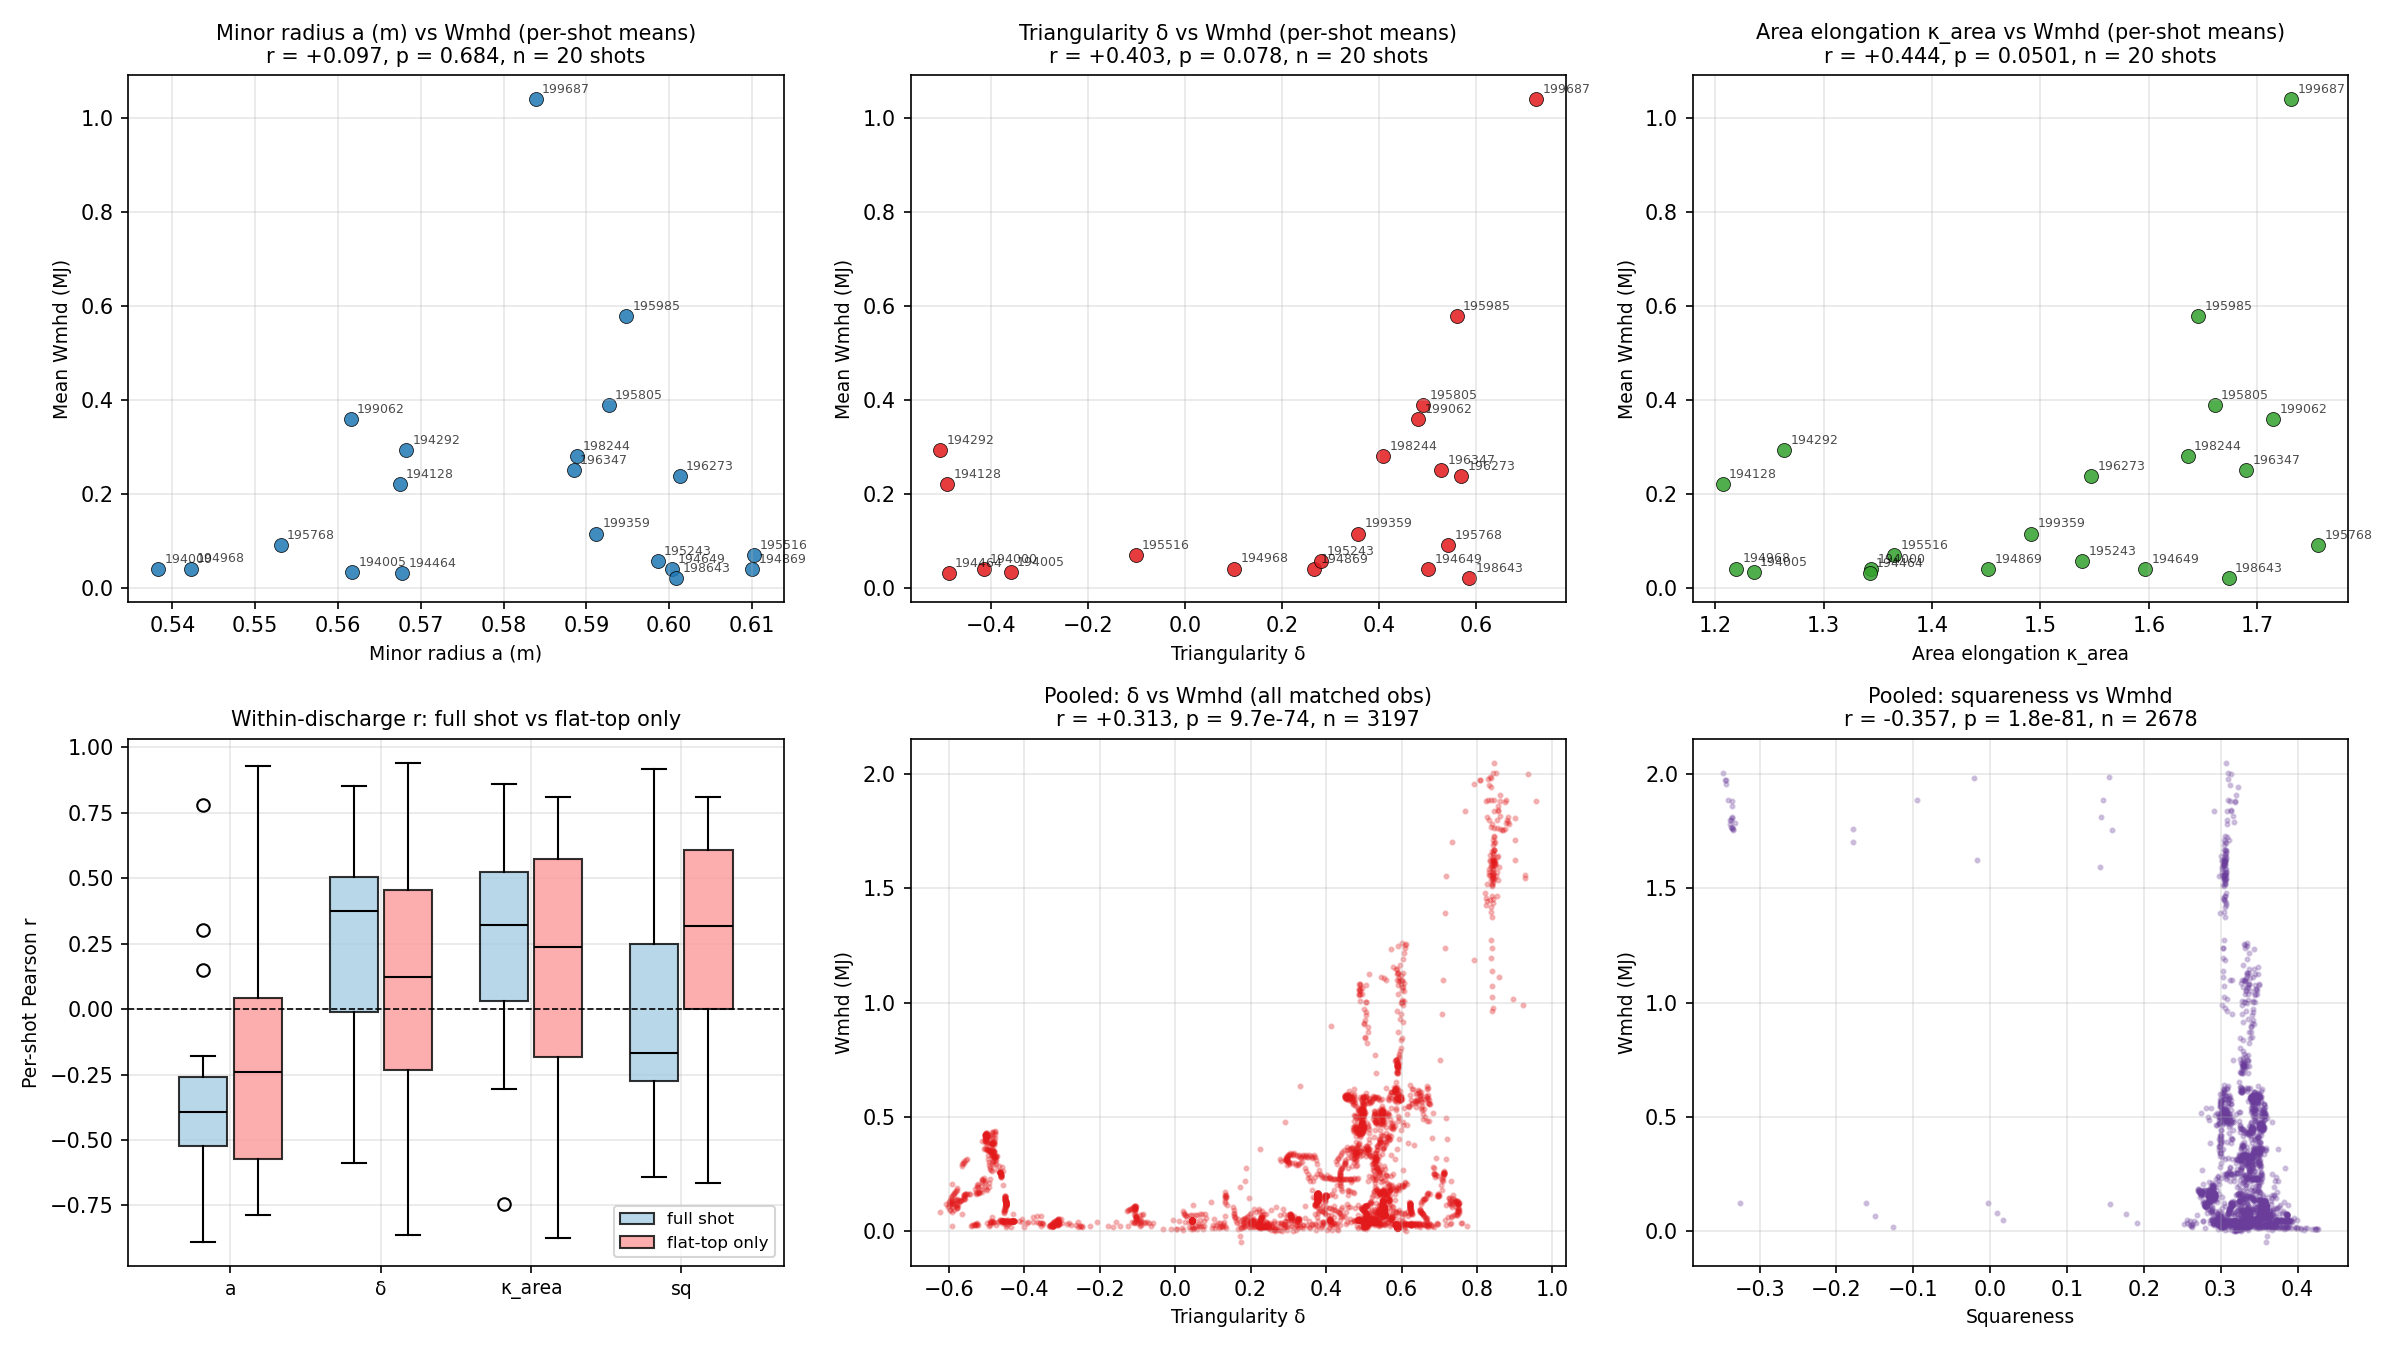

## Data files

- `shape_energy_matched.csv` — all 3,778 matched rows (shot, time, idx, ip, 4 shapes, wmhd, wmhd_rt).
- `shape_energy_per_shot.csv` — per-discharge pairwise means and per-shot Pearson r/p for each shape.
- `shape_energy_pooled.csv` — pooled Pearson/Spearman per shape.
- `shape_energy_between_shot.csv` — between-discharge correlations on per-shot means.
- `shape_energy_flattop.csv` — flat-top-only per-shot correlations (robustness check).
- `shape_energy_summary.json` — machine-readable summary with provenance and caveats.

In [2]:
%%ask
For each discharge, how are minor radius, triangularity, area elongation, 
and squareness associated with plasma thermal stored energy? Match 
observations by shot, sample index, and time, then compute pairwise means 
and Pearson correlations for each shape parameter against stored energy.

## What this run showed

All six questions produced answers. Our own expectations beforehand were wrong
four times: we judged Q2 and Q4 unanswerable, under-counted the obstacles in Q3,
and expected Q5 to be declined on units. In each case the agent found a route we
had not.

Three answers carry findings that are **not yet confirmed with their providers**
and should be read as questions rather than conclusions: the programmed-current
conversion in Q1, the technique disagreement in Q5, and the matched-cohort
association in Q2.

On the ontology specifically: it is load-bearing in **Q4**, where the class
hierarchy defines what "explicitly modelled" means and our tables could not have
supplied that list. **Q5** is the next clearest case, since unit compatibility is
the substance of the question. For Q1, Q2 and Q6 the vocabulary the questions
needed was already carried by the disruption index's own parameter dictionary,
where each column has a long name and units.
